# 05 — Integrated Evaluation and Business Insights

## Purpose

This notebook combines the passenger-demand, forecasting and punctuality
results developed in the earlier notebooks. It translates the technical
analysis into a concise set of operational and strategic insights.

## Objectives

1. Load and validate the final processed datasets.
2. combine passenger demand, forecast performance and punctuality measures;
3. assess demand recovery alongside operational performance;
4. create a concise airport performance scorecard;
5. summarise the forecasting evidence;
6. identify practical business implications and limitations;
7. export final portfolio-ready summary tables.

## Scope

The analysis covers monthly UK airport data from January 2015 to December 2025.
Passenger and punctuality measures originate from official UK Civil Aviation
Authority data.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

interim_dir = project_root / "data" / "interim"
processed_dir = project_root / "data" / "processed"

print(f"Project root: {project_root}")
print(f"Interim directory: {interim_dir}")
print(f"Processed directory: {processed_dir}")

Project root: /Users/dafyddjones/projects/uk-aviation-demand-punctuality
Interim directory: /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/interim
Processed directory: /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed


## 1. Load the final analysis datasets

The notebook uses the cleaned and processed outputs created by the preceding
notebooks. Keeping these outputs separate avoids repeating the full web
collection and cleaning process.

In [2]:
data_files = {
    "passengers": (
        interim_dir
        / "caa_monthly_airport_passengers_2015_2025.csv"
    ),
    "punctuality": (
        interim_dir
        / "caa_monthly_airport_punctuality_2015_2025.csv"
    ),
    "forecast_results": (
        processed_dir
        / "forecast_results_2025.csv"
    ),
    "forecast_metrics": (
        processed_dir
        / "forecast_model_metrics.csv"
    ),
    "backtest_metrics": (
        processed_dir
        / "uk_annual_backtest_metrics.csv"
    ),
    "airport_punctuality_2025": (
        processed_dir
        / "punctuality_airport_performance_2025.csv"
    ),
    "annual_punctuality": (
        processed_dir
        / "punctuality_annual_summary_2015_2025.csv"
    ),
    "monthly_relationship": (
        processed_dir
        / "monthly_demand_and_punctuality_2015_2025.csv"
    ),
}

missing_files = [
    str(path)
    for path in data_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(missing_files)
    )

passengers = pd.read_csv(
    data_files["passengers"],
    parse_dates=["period_date"],
)

punctuality = pd.read_csv(
    data_files["punctuality"],
    parse_dates=["period_date"],
)

forecast_results = pd.read_csv(
    data_files["forecast_results"],
    parse_dates=["period_date"],
)

forecast_metrics = pd.read_csv(
    data_files["forecast_metrics"],
)

backtest_metrics = pd.read_csv(
    data_files["backtest_metrics"],
)

airport_punctuality_2025 = pd.read_csv(
    data_files["airport_punctuality_2025"],
)

annual_punctuality = pd.read_csv(
    data_files["annual_punctuality"],
)

monthly_relationship = pd.read_csv(
    data_files["monthly_relationship"],
    parse_dates=["period_date"],
)

dataset_summary = pd.DataFrame(
    {
        "dataset": [
            "Passenger history",
            "Punctuality history",
            "2025 forecasts",
            "Forecast metrics",
            "Annual backtest metrics",
            "2025 airport punctuality",
            "Annual punctuality",
            "Monthly demand-punctuality",
        ],
        "rows": [
            len(passengers),
            len(punctuality),
            len(forecast_results),
            len(forecast_metrics),
            len(backtest_metrics),
            len(airport_punctuality_2025),
            len(annual_punctuality),
            len(monthly_relationship),
        ],
        "columns": [
            passengers.shape[1],
            punctuality.shape[1],
            forecast_results.shape[1],
            forecast_metrics.shape[1],
            backtest_metrics.shape[1],
            airport_punctuality_2025.shape[1],
            annual_punctuality.shape[1],
            monthly_relationship.shape[1],
        ],
    }
)

display(dataset_summary)

,dataset,rows,columns
0,Passenger history,6230,8
1,Punctuality history,3354,12
2,2025 forecasts,132,7
3,Forecast metrics,22,5
4,Annual backtest metrics,10,4
5,2025 airport punctuality,25,10
6,Annual punctuality,11,9
7,Monthly demand-punctuality,132,6


## 2. Validate the integrated inputs

Before combining the results, the principal coverage, uniqueness and
completeness checks are repeated. This confirms that the final evaluation uses
the intended outputs from the earlier notebooks.

In [3]:
validation_summary = {
    "passenger_months": passengers["period_date"].nunique(),
    "passenger_airports": passengers["airport_name"].nunique(),
    "passenger_duplicates": passengers.duplicated(
        ["airport_name", "period_date"]
    ).sum(),
    "punctuality_months": punctuality["period_date"].nunique(),
    "punctuality_airports": punctuality["airport_name"].nunique(),
    "punctuality_duplicates": punctuality.duplicated(
        ["airport_name", "period_date"]
    ).sum(),
    "forecast_rows": len(forecast_results),
    "forecast_series": forecast_results["series_name"].nunique(),
    "forecast_months": forecast_results["period_date"].nunique(),
    "missing_actual_forecast_values": (
        forecast_results["actual_passengers"].isna().sum()
    ),
}

for check, value in validation_summary.items():
    print(f"{check}: {value}")

assert validation_summary["passenger_months"] == 132
assert validation_summary["passenger_duplicates"] == 0
assert validation_summary["punctuality_months"] == 132
assert validation_summary["punctuality_duplicates"] == 0
assert validation_summary["forecast_rows"] == 132
assert validation_summary["forecast_series"] == 11
assert validation_summary["forecast_months"] == 12
assert validation_summary["missing_actual_forecast_values"] == 0

print("\nAll integrated-input validation checks passed.")

print("\nForecast-result columns:")
print(forecast_results.columns.tolist())

print("\nForecast-metric columns:")
print(forecast_metrics.columns.tolist())

passenger_months: 132
passenger_airports: 54
passenger_duplicates: 0
punctuality_months: 132
punctuality_airports: 27
punctuality_duplicates: 0
forecast_rows: 132
forecast_series: 11
forecast_months: 12
missing_actual_forecast_values: 0

All integrated-input validation checks passed.

Forecast-result columns:
['period_date', 'series_name', 'actual_passengers', 'seasonal_naive_prediction', 'holt_winters_prediction', 'seasonal_naive_error', 'holt_winters_error']

Forecast-metric columns:
['series_name', 'model', 'MAE', 'RMSE', 'MAPE']


## 3. Executive KPI summary

The following measures bring together the principal demand, forecasting and
punctuality findings. They provide a concise view of market recovery and
operational performance in 2025.

In [4]:
annual_passengers = (
    passengers
    .assign(year=passengers["period_date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        terminal_passengers=(
            "terminal_passengers",
            "sum",
        )
    )
)

passengers_2019 = annual_passengers.loc[
    annual_passengers["year"] == 2019,
    "terminal_passengers",
].iloc[0]

passengers_2025 = annual_passengers.loc[
    annual_passengers["year"] == 2025,
    "terminal_passengers",
].iloc[0]

passenger_change_vs_2019 = (
    100
    * (passengers_2025 - passengers_2019)
    / passengers_2019
)

punctuality_2019 = annual_punctuality.loc[
    annual_punctuality["year"] == 2019
].iloc[0]

punctuality_2025 = annual_punctuality.loc[
    annual_punctuality["year"] == 2025
].iloc[0]

uk_forecast_metrics = (
    forecast_metrics[
        forecast_metrics["series_name"] == "UK TOTAL"
    ]
    .sort_values("MAPE")
)

best_uk_model = uk_forecast_metrics.iloc[0]

executive_kpis = pd.DataFrame(
    {
        "KPI": [
            "2025 terminal passengers",
            "Change in passengers vs 2019",
            "2025 on-time flights",
            "Change in on-time rate vs 2019",
            "2025 average delay",
            "Change in average delay vs 2019",
            "2025 cancellation rate",
            "Best UK forecast model",
            "Best UK forecast MAPE",
        ],
        "Value": [
            f"{passengers_2025 / 1_000_000:.1f} million",
            f"{passenger_change_vs_2019:+.1f}%",
            f"{punctuality_2025['on_time_percent']:.1f}%",
            (
                f"{punctuality_2025['on_time_percent'] - punctuality_2019['on_time_percent']:+.1f}"
                " percentage points"
            ),
            (
                f"{punctuality_2025['average_delay_minutes']:.1f}"
                " minutes"
            ),
            (
                f"{punctuality_2025['average_delay_minutes'] - punctuality_2019['average_delay_minutes']:+.1f}"
                " minutes"
            ),
            f"{punctuality_2025['cancelled_percent']:.2f}%",
            best_uk_model["model"],
            f"{best_uk_model['MAPE']:.2f}%",
        ],
    }
)

display(executive_kpis)

,KPI,Value
0,2025 terminal passengers,299.4 million
1,Change in passengers vs 2019,+0.9%
2,2025 on-time flights,72.7%
3,Change in on-time rate vs 2019,-2.3 percentage points
4,2025 average delay,15.1 minutes
5,Change in average delay vs 2019,+1.1 minutes
6,2025 cancellation rate,1.04%
7,Best UK forecast model,Seasonal naive
8,Best UK forecast MAPE,2.40%


## 4. Integrated airport performance scorecard

The scorecard combines 2025 passenger demand with operational performance.
It shows airport scale, recovery relative to 2019, on-time performance, average
delay and cancellations in one table.

The comparison is descriptive: airport size, route mix, airline mix and local
operating conditions differ substantially.

In [5]:
airport_annual_passengers = (
    passengers[
        passengers["period_date"].dt.year.isin([2019, 2025])
    ]
    .assign(year=passengers["period_date"].dt.year)
    .groupby(
        ["airport_name", "year"],
        as_index=False,
    )
    .agg(
        terminal_passengers=(
            "terminal_passengers",
            "sum",
        )
    )
)

airport_passenger_comparison = (
    airport_annual_passengers
    .pivot(
        index="airport_name",
        columns="year",
        values="terminal_passengers",
    )
    .reset_index()
    .rename(
        columns={
            2019: "passengers_2019",
            2025: "passengers_2025",
        }
    )
)

airport_passenger_comparison["change_vs_2019_pct"] = (
    100
    * (
        airport_passenger_comparison["passengers_2025"]
        - airport_passenger_comparison["passengers_2019"]
    )
    / airport_passenger_comparison["passengers_2019"]
)

airport_passenger_comparison["passengers_2025_millions"] = (
    airport_passenger_comparison["passengers_2025"]
    / 1_000_000
)

airport_passenger_comparison["market_share_2025_pct"] = (
    100
    * airport_passenger_comparison["passengers_2025"]
    / passengers_2025
)

airport_scorecard = airport_punctuality_2025.merge(
    airport_passenger_comparison,
    on="airport_name",
    how="left",
    validate="one_to_one",
)

airport_scorecard = airport_scorecard[
    [
        "airport_name",
        "passengers_2025_millions",
        "market_share_2025_pct",
        "change_vs_2019_pct",
        "on_time_percent",
        "average_delay_minutes",
        "cancelled_percent",
        "flights_matched",
    ]
].sort_values(
    "passengers_2025_millions",
    ascending=False,
)

print("Punctuality airports:", len(airport_punctuality_2025))
print(
    "Airports matched to passenger data:",
    airport_scorecard["passengers_2025_millions"]
    .notna()
    .sum(),
)

display(
    airport_scorecard.head(15).round(
        {
            "passengers_2025_millions": 1,
            "market_share_2025_pct": 1,
            "change_vs_2019_pct": 1,
            "on_time_percent": 1,
            "average_delay_minutes": 1,
            "cancelled_percent": 2,
        }
    )
)

Punctuality airports: 25
Airports matched to passenger data: 23


,airport_name,passengers_2025_millions,market_share_2025_pct,change_vs_2019_pct,on_time_percent,average_delay_minutes,cancelled_percent,flights_matched
7,HEATHROW,84.50,28.20,4.40,76.80,12.80,1.32,"475,582.00"
20,GATWICK,42.80,14.30,-8.20,69.80,16.80,0.82,"259,343.00"
24,MANCHESTER,32.10,10.70,9.20,64.50,19.80,0.96,"194,144.00"
21,STANSTED,29.80,9.90,5.80,69.70,16.30,0.31,"179,552.00"
13,LUTON,17.80,5.90,-2.40,73.40,15.10,0.35,"103,374.00"
18,EDINBURGH,17.00,5.70,15.20,71.50,15.30,1.08,"117,231.00"
22,BIRMINGHAM,13.70,4.60,8.00,68.00,17.80,0.94,"90,491.00"
19,BRISTOL,10.80,3.60,20.90,70.30,16.20,0.61,"72,001.00"
5,GLASGOW,8.20,2.70,-7.20,77.30,12.10,1.76,"66,129.00"
2,BELFAST INTERNATIONAL,6.70,2.20,6.30,78.70,12.70,0.51,"45,244.00"


In [6]:
unmatched_scorecard_airports = airport_scorecard.loc[
    airport_scorecard["passengers_2025_millions"].isna(),
    "airport_name",
].tolist()

print(
    "Punctuality airports without UK passenger records:",
    unmatched_scorecard_airports,
)

integrated_airport_scorecard = (
    airport_scorecard
    .dropna(
        subset=[
            "passengers_2025_millions",
            "on_time_percent",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Airports retained in integrated scorecard:",
    len(integrated_airport_scorecard),
)

Punctuality airports without UK passenger records: ['ISLE OF MAN', 'JERSEY']
Airports retained in integrated scorecard: 23


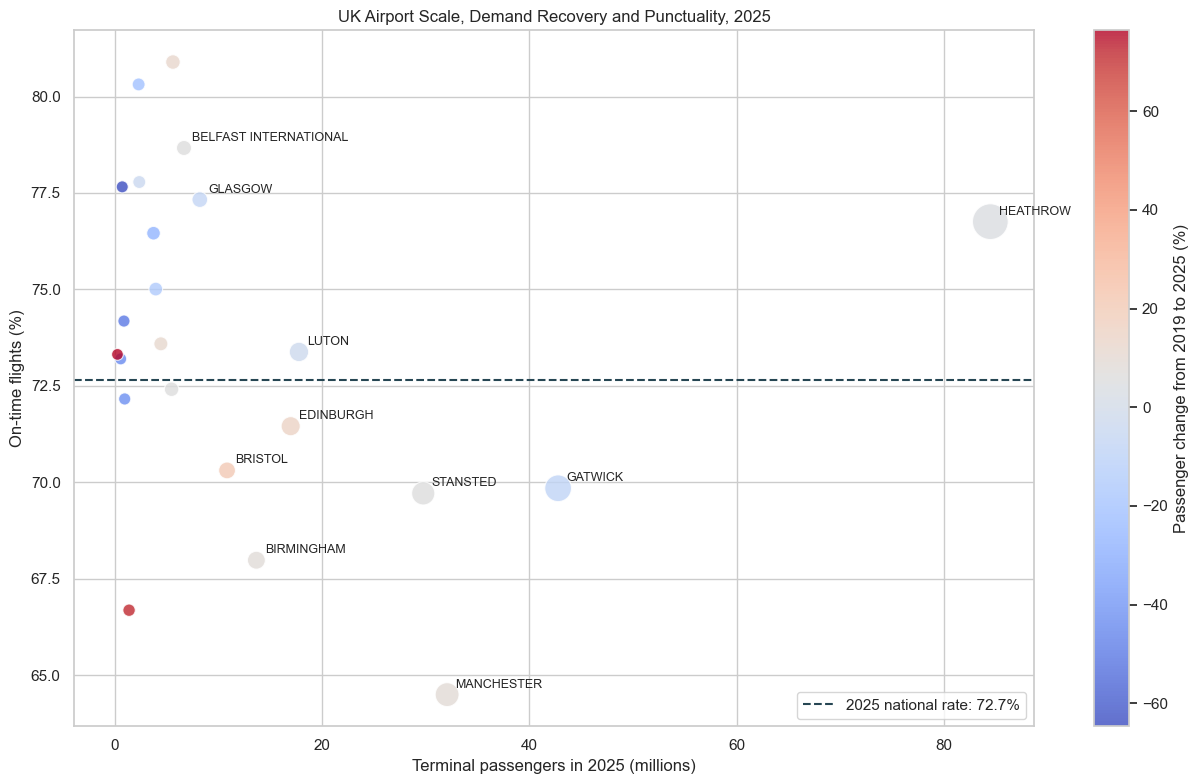

In [7]:
scorecard_plot = integrated_airport_scorecard.copy()

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    scorecard_plot["passengers_2025_millions"],
    scorecard_plot["on_time_percent"],
    c=scorecard_plot["change_vs_2019_pct"],
    s=(
        70
        + scorecard_plot["passengers_2025_millions"] * 7
    ),
    cmap="coolwarm",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.8,
)

national_on_time_2025 = punctuality_2025[
    "on_time_percent"
]

ax.axhline(
    national_on_time_2025,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"2025 national rate: "
        f"{national_on_time_2025:.1f}%"
    ),
)

largest_airports = scorecard_plot.nlargest(
    10,
    "passengers_2025_millions",
)

for _, row in largest_airports.iterrows():
    ax.annotate(
        row["airport_name"],
        (
            row["passengers_2025_millions"],
            row["on_time_percent"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
    )

colour_bar = plt.colorbar(
    scatter,
    ax=ax,
)

colour_bar.set_label(
    "Passenger change from 2019 to 2025 (%)"
)

ax.set_title(
    "UK Airport Scale, Demand Recovery and Punctuality, 2025"
)
ax.set_xlabel("Terminal passengers in 2025 (millions)")
ax.set_ylabel("On-time flights (%)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 5. Forecast-model evaluation

Forecast accuracy is evaluated using the 2025 holdout period. Seasonal naive
uses the corresponding month from the previous year, while Holt-Winters models
trend and seasonal structure.

Lower MAPE indicates greater forecast accuracy. A complex model is only useful
when it improves upon the simpler baseline.

In [8]:
model_comparison = (
    forecast_metrics
    .pivot(
        index="series_name",
        columns="model",
        values="MAPE",
    )
    .reset_index()
)

model_columns = [
    column
    for column in model_comparison.columns
    if column != "series_name"
]

model_comparison["best_model"] = (
    model_comparison[model_columns]
    .idxmin(axis=1)
)

model_comparison["best_MAPE"] = (
    model_comparison[model_columns]
    .min(axis=1)
)

model_comparison = model_comparison.sort_values(
    "best_MAPE"
).reset_index(drop=True)

print("Best-model counts:")
display(
    model_comparison["best_model"]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="series_count")
)

display(
    model_comparison.style.format(
        {
            "Holt-Winters": "{:.2f}%",
            "Seasonal naive": "{:.2f}%",
            "best_MAPE": "{:.2f}%",
        }
    )
)

Best-model counts:


,model,series_count
0,Seasonal naive,8
1,Holt-Winters,3


model,series_name,Holt-Winters,Seasonal naive,best_model,best_MAPE
0,STANSTED,6.41%,1.80%,Seasonal naive,1.80%
1,UK TOTAL,12.51%,2.40%,Seasonal naive,2.40%
2,HEATHROW,12.63%,2.42%,Seasonal naive,2.42%
3,GATWICK,18.16%,2.45%,Seasonal naive,2.45%
4,BELFAST INTERNATIONAL,3.68%,2.57%,Seasonal naive,2.57%
5,GLASGOW,20.99%,2.72%,Seasonal naive,2.72%
6,BRISTOL,8.84%,3.25%,Seasonal naive,3.25%
7,MANCHESTER,3.91%,4.31%,Holt-Winters,3.91%
8,BIRMINGHAM,4.59%,6.00%,Holt-Winters,4.59%
9,LUTON,9.38%,4.86%,Seasonal naive,4.86%


### 5.1 Forecast robustness across operating conditions

A model can perform well in a stable year but fail during a structural shock.
The rolling annual backtest therefore separates relatively stable periods from
the pandemic disruption and recovery period.

In [9]:
backtest_evaluation = backtest_metrics.copy()

backtest_evaluation["operating_period"] = np.select(
    [
        backtest_evaluation["year"].between(2016, 2019),
        backtest_evaluation["year"].between(2020, 2023),
        backtest_evaluation["year"].between(2024, 2025),
    ],
    [
        "Stable pre-pandemic",
        "Disruption and recovery",
        "Recent period",
    ],
    default="Other",
)

backtest_period_summary = (
    backtest_evaluation
    .groupby(
        "operating_period",
        as_index=False,
    )
    .agg(
        years=("year", "count"),
        average_MAPE=("MAPE", "mean"),
        median_MAPE=("MAPE", "median"),
        minimum_MAPE=("MAPE", "min"),
        maximum_MAPE=("MAPE", "max"),
    )
)

period_order = [
    "Stable pre-pandemic",
    "Disruption and recovery",
    "Recent period",
]

backtest_period_summary["operating_period"] = pd.Categorical(
    backtest_period_summary["operating_period"],
    categories=period_order,
    ordered=True,
)

backtest_period_summary = (
    backtest_period_summary
    .sort_values("operating_period")
    .reset_index(drop=True)
)

display(
    backtest_period_summary.style.format(
        {
            "average_MAPE": "{:.2f}%",
            "median_MAPE": "{:.2f}%",
            "minimum_MAPE": "{:.2f}%",
            "maximum_MAPE": "{:.2f}%",
        }
    )
)

,operating_period,years,average_MAPE,median_MAPE,minimum_MAPE,maximum_MAPE
0,Stable pre-pandemic,4,4.39%,4.44%,2.18%,6.49%
1,Disruption and recovery,4,582.04%,231.56%,20.49%,1844.55%
2,Recent period,2,4.67%,4.67%,2.40%,6.95%


## 6. Airport opportunity and operational-risk groups

Airports are classified using two dimensions:

- whether 2025 passenger demand was above or below 2019;
- whether 2025 on-time performance was above or below the national rate.

The categories are intended as a concise decision-support summary rather than a
complete assessment of airport quality.

In [10]:
integrated_airport_scorecard["performance_group"] = np.select(
    [
        (
            integrated_airport_scorecard["change_vs_2019_pct"] >= 0
        )
        & (
            integrated_airport_scorecard["on_time_percent"]
            >= national_on_time_2025
        ),
        (
            integrated_airport_scorecard["change_vs_2019_pct"] >= 0
        )
        & (
            integrated_airport_scorecard["on_time_percent"]
            < national_on_time_2025
        ),
        (
            integrated_airport_scorecard["change_vs_2019_pct"] < 0
        )
        & (
            integrated_airport_scorecard["on_time_percent"]
            >= national_on_time_2025
        ),
        (
            integrated_airport_scorecard["change_vs_2019_pct"] < 0
        )
        & (
            integrated_airport_scorecard["on_time_percent"]
            < national_on_time_2025
        ),
    ],
    [
        "Resilient growth",
        "Growth with operational pressure",
        "Demand recovery opportunity",
        "Demand and operational pressure",
    ],
    default="Unclassified",
)

group_summary = (
    integrated_airport_scorecard
    .groupby(
        "performance_group",
        as_index=False,
    )
    .agg(
        airports=("airport_name", "count"),
        passengers_2025_millions=(
            "passengers_2025_millions",
            "sum",
        ),
        average_on_time_percent=(
            "on_time_percent",
            "mean",
        ),
        airport_names=(
            "airport_name",
            lambda values: ", ".join(
                sorted(values)
            ),
        ),
    )
    .sort_values(
        "passengers_2025_millions",
        ascending=False,
    )
)

display(
    group_summary.style.format(
        {
            "passengers_2025_millions": "{:.1f}",
            "average_on_time_percent": "{:.1f}%",
        }
    )
)

,performance_group,airports,passengers_2025_millions,average_on_time_percent,airport_names
2,Growth with operational pressure,7,110.1,69.0%,"BIRMINGHAM, BOURNEMOUTH, BRISTOL, EDINBURGH, MANCHESTER, NEWCASTLE, STANSTED"
3,Resilient growth,5,101.5,76.6%,"BELFAST INTERNATIONAL, HEATHROW, LEEDS BRADFORD, LIVERPOOL (JOHN LENNON), TEESSIDE INTERNATIONAL AIRPORT"
0,Demand and operational pressure,2,43.7,71.0%,"CARDIFF WALES, GATWICK"
1,Demand recovery opportunity,9,40.5,76.1%,"ABERDEEN, BELFAST CITY (GEORGE BEST), EAST MIDLANDS INTERNATIONAL, EXETER, GLASGOW, LONDON CITY, LUTON, SOUTHAMPTON, SOUTHEND"


## 7. Business implications and recommendations

### 1. Protect capacity during peak summer demand

Punctuality deteriorates materially during the summer peak. July recorded the
weakest normal-period performance, with 62.7% of flights on time and an average
delay of 21.6 minutes. Airports and airlines should therefore stress-test
staffing, stands, ground handling and disruption-response plans before the peak
season.

### 2. Prioritise airports experiencing growth with operational pressure

Birmingham, Bournemouth, Bristol, Edinburgh, Manchester, Newcastle and Stansted
all exceeded their 2019 passenger levels but recorded below-national punctuality
in 2025. This does not establish the cause of delay, but it identifies locations
where demand growth and operational performance should be investigated
together.

Manchester is the most prominent example among the major airports: passenger
demand was 9.2% above 2019, while only 64.5% of flights were on time and average
delay reached 19.8 minutes.

### 3. Learn from airports combining growth and resilience

The resilient-growth group includes Belfast International, Heathrow, Leeds
Bradford, Liverpool (John Lennon) and Teesside International Airport. These
airports combined demand above 2019 levels with on-time performance above the
2025 national benchmark. Their operating practices may provide useful
comparators, subject to differences in scale, route mix and airline mix.

### 4. Use simple forecasts as an operational baseline

Seasonal naive was the most accurate 2025 model for eight of the eleven series,
including the UK total. Its UK MAPE was 2.40%. Holt-Winters performed better for
Manchester, Birmingham and Edinburgh, supporting airport-specific rather than
one-size-fits-all model selection.

Forecasting should use a baseline-and-challenger approach:

- retain seasonal naive as a transparent benchmark;
- use Holt-Winters only where backtesting demonstrates an improvement;
- monitor accuracy regularly by airport;
- add scenario adjustments for known capacity changes and major events.

### 5. Do not treat statistical forecasts as shock predictions

Seasonal models performed well during stable periods but failed during the
pandemic and reopening. Forecasts should therefore be accompanied by scenarios,
risk ranges and management judgement rather than treated as single-point
certainties.

## 8. Limitations

- The analysis uses aggregate monthly data and cannot identify individual
  airlines, routes, times of day or specific causes of delay.
- Correlation between passenger demand and punctuality does not prove causation.
- Weather, air-traffic restrictions, industrial action and local capacity
  constraints are not separately modelled.
- Punctuality reporting covers a defined set of CAA airports, while the passenger
  dataset includes a wider set of UK-reporting airports.
- Isle of Man and Jersey appear in punctuality reporting but are excluded from
  the integrated UK passenger scorecard.
- The airport performance groups use national-average and 2019-recovery
  thresholds. They are screening indicators rather than definitive rankings.
- Cancellation measures are only consistently available from 2018.
- Historical seasonal models cannot anticipate unprecedented structural shocks.

In [11]:
final_outputs = {
    "executive_kpis": (
        processed_dir / "final_executive_kpis.csv"
    ),
    "airport_scorecard": (
        processed_dir / "final_airport_scorecard_2025.csv"
    ),
    "forecast_model_comparison": (
        processed_dir / "final_forecast_model_comparison.csv"
    ),
    "airport_performance_groups": (
        processed_dir / "final_airport_performance_groups.csv"
    ),
    "backtest_period_summary": (
        processed_dir / "final_backtest_period_summary.csv"
    ),
}

executive_kpis.to_csv(
    final_outputs["executive_kpis"],
    index=False,
)

integrated_airport_scorecard.sort_values(
    "passengers_2025_millions",
    ascending=False,
).to_csv(
    final_outputs["airport_scorecard"],
    index=False,
)

model_comparison.to_csv(
    final_outputs["forecast_model_comparison"],
    index=False,
)

group_summary.to_csv(
    final_outputs["airport_performance_groups"],
    index=False,
)

backtest_period_summary.to_csv(
    final_outputs["backtest_period_summary"],
    index=False,
)

key_scorecard_columns = [
    "airport_name",
    "passengers_2025_millions",
    "change_vs_2019_pct",
    "on_time_percent",
    "average_delay_minutes",
    "performance_group",
]

validation_checks = {
    "executive_kpis": len(executive_kpis),
    "scorecard_airports": len(integrated_airport_scorecard),
    "scorecard_duplicates": int(
        integrated_airport_scorecard["airport_name"]
        .duplicated()
        .sum()
    ),
    "scorecard_rows_missing_key_values": int(
        integrated_airport_scorecard[
            key_scorecard_columns
        ]
        .isna()
        .any(axis=1)
        .sum()
    ),
    "classified_airports": int(
        group_summary["airports"].sum()
    ),
    "forecast_series_compared": len(model_comparison),
    "performance_groups": len(group_summary),
}

for check, value in validation_checks.items():
    print(f"{check}: {value}")

assert validation_checks["executive_kpis"] == 9
assert validation_checks["scorecard_airports"] == 23
assert validation_checks["scorecard_duplicates"] == 0
assert validation_checks["scorecard_rows_missing_key_values"] == 0
assert validation_checks["classified_airports"] == 23
assert validation_checks["forecast_series_compared"] == 11
assert validation_checks["performance_groups"] == 4

print("\nAll final integrated-analysis checks passed.")

print("\nExported files:")
for output_path in final_outputs.values():
    print(output_path)

executive_kpis: 9
scorecard_airports: 23
scorecard_duplicates: 0
scorecard_rows_missing_key_values: 0
classified_airports: 23
forecast_series_compared: 11
performance_groups: 4

All final integrated-analysis checks passed.

Exported files:
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/final_executive_kpis.csv
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/final_airport_scorecard_2025.csv
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/final_forecast_model_comparison.csv
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/final_airport_performance_groups.csv
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/final_backtest_period_summary.csv
